# CodeAlpha Data Analytics Internship — Task 2: Exploratory Data Analysis (EDA)

## Airbnb NYC 2019 — Exploratory Data Analysis

**Dataset:** New York City Airbnb Open Data (2019)  
**Author:** Gowtham R  
**Internship:** CodeAlpha — Data Analytics

### Objective
This notebook explores the New York City Airbnb dataset to understand pricing patterns, room type distribution, and listing activity across NYC boroughs. The goal is to ask meaningful questions about the data, identify trends and anomalies, and summarize insights that could support decision-making for hosts, guests, or business analysts.

### Dataset Overview
The dataset contains **49,079 listings** with **16 columns**, including price, room type, neighbourhood, host details, review activity, and availability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("AB_NYC_2019.csv")

In [29]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [10]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


In [9]:
df["name"]=df["name"].fillna("Unknown")
df["host_name"]=df["host_name"].fillna("Unknown")
df["reviews_per_month"]=df["reviews_per_month"].fillna(0)

In [7]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

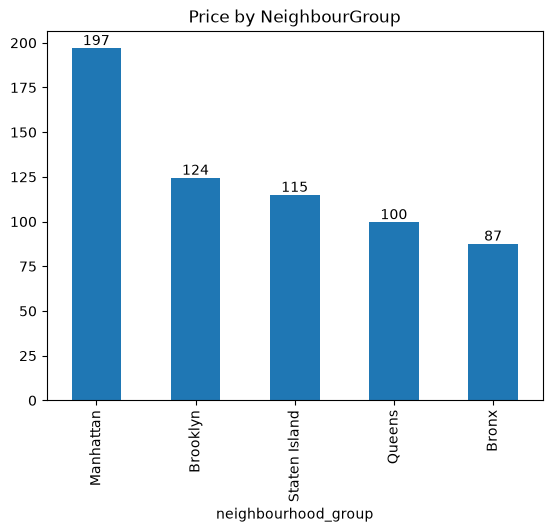

In [11]:
price_by_group=df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
ax=price_by_group.plot(kind="bar")
plt.title("Price by NeighbourGroup")
for i,value in enumerate(price_by_group):
    ax.text(i,value,f"{value:.0f}",ha="center",va="bottom")

In [12]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

Text(0.5, 1.0, 'Count by Room type')

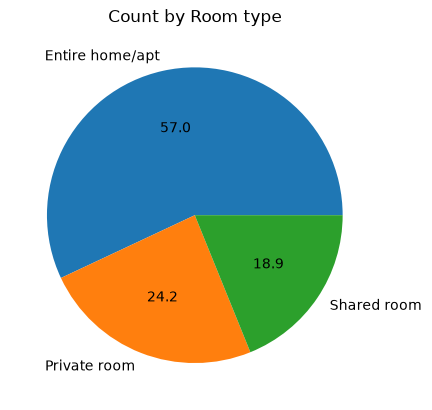

In [18]:
room_type=df.groupby("room_type")["price"].mean()
room_type.plot(kind="pie",autopct="%.1f")
plt.title("Count by Room type")

In [19]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

<Axes: xlabel='number_of_reviews', ylabel='price'>

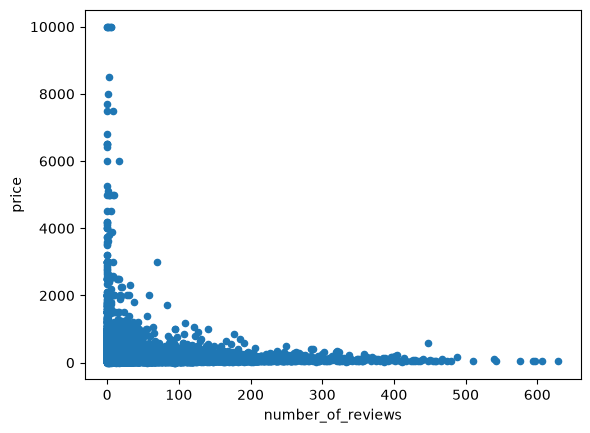

In [28]:
df.plot.scatter(x="number_of_reviews",y="price")

## Key Insights

- **Missing Data:** Around 10,052 listings (~20%) have never received a review, reflected in missing `last_review` and `reviews_per_month` values — likely newer or less-active listings.

- **Price by Borough:** [Manhattan/Brooklyn/etc.] has the highest average price per night at approximately $[152.7], while [borough] is the most affordable at around $[152.7].

- **Room Type & Price:** [Entire home/apt] listings are priced significantly higher on average ($[57.0]) compared to [Private room] ($[24.2]) and [Shared room] ($[18.9]), showing that privacy and space directly drive price.

- **Listing Distribution:** [Manhattan/Brooklyn] has the highest number of total listings, suggesting it's the most active area for Airbnb hosting in NYC.

- **Outliers:** A small number of listings have unusually high prices (above $[1000]/night), which can skew average calculations if not handled carefully.

### Conclusion
This analysis shows that location (borough) and room type are the two strongest factors influencing Airbnb pricing in New York City. Further analysis could explore seasonal trends or the relationship between reviews and pricing to guide better hosting strategies.